In [12]:
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import numpy as np

In [2]:
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

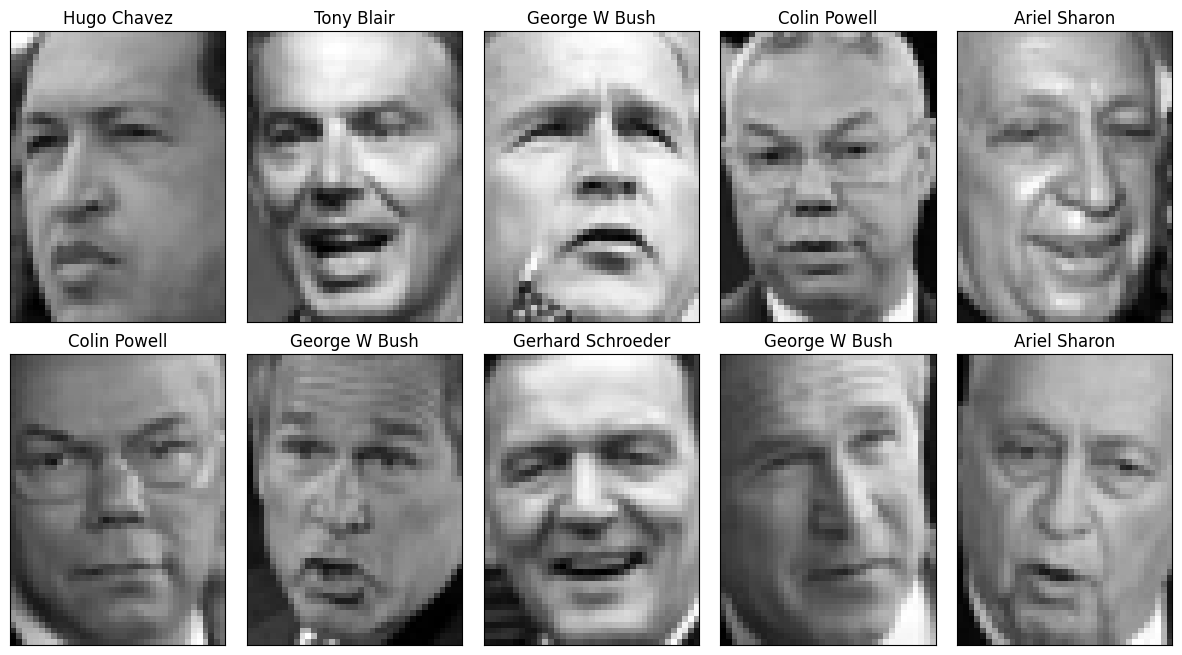

In [10]:
# Plot N samples 
N = 10
fig, axes = plt.subplots(2, N//2, figsize=(15, 8),
                         subplot_kw={'xticks':[], 'yticks':[]},
                            gridspec_kw=dict(hspace=0.1, wspace=0.1))
for i, ax in enumerate(axes.flat):
    ax.imshow(lfw_people.images[i], cmap='gray')
    ax.set_title(lfw_people.target_names[lfw_people.target[i]])
plt.show()

In [13]:
train_faces, test_faces, train_labels, test_labels = train_test_split(
    lfw_people.data, lfw_people.target, random_state=42)

In [ ]:
mean_face = np.mean(train_faces, axis=0)
centered_train_faces = train_faces - mean_face
covariance_matrix = np.cov(centered_train_faces, rowvar=False)

eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

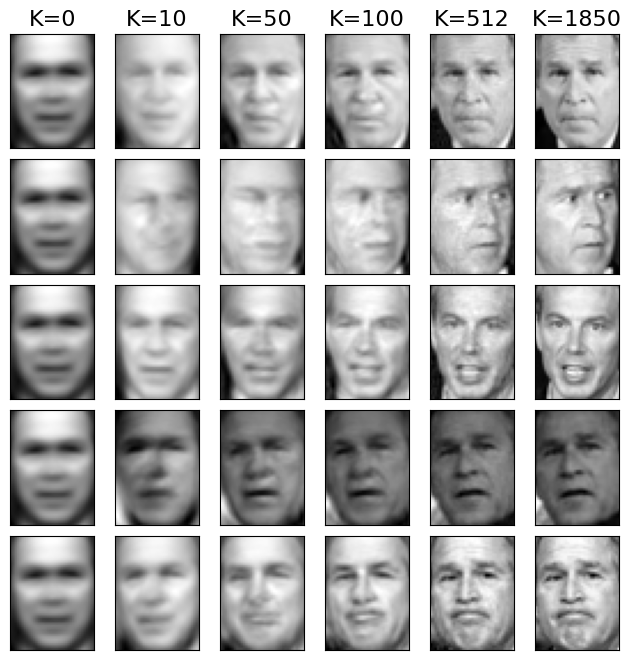

In [32]:
Ks = [0, 10, 50, 100, 512, len(eigenvalues)]
N_samples = 5
fig, axes = plt.subplots(N_samples, len(Ks), figsize=(8, 8),
                         subplot_kw={'xticks':[], 'yticks':[]},
                            gridspec_kw=dict(hspace=0.1, wspace=0.1))

for col, K in enumerate(Ks):
    axes[0, col].set_title(f'K={K}', fontsize=16)
    for row in range(N_samples):
        original_face = test_faces[row]
        centered_face = original_face - mean_face
        projected_face = centered_face @ eigenvectors[:, :K] @ eigenvectors[:, :K].T
        reconstructed_face = projected_face + mean_face
        axes[row, col].imshow(reconstructed_face.reshape(lfw_people.images[0].shape), cmap='gray')